# RAFT Fine-Tuning Llama 3.1 8B — Unsloth + LoRA (Dataset v5)

Notebook ini adalah versi perbaikan untuk dataset RAFT v5.

Perubahan utama:

- memakai file train, validation, dan test yang sudah dipisahkan;
- tidak melakukan `train_test_split` ulang;
- tidak membuat label berdasarkan lexical overlap;
- memakai `selected_doc_ids` dan `rejected_doc_ids` sebagai ground truth;
- memakai dataset `prompt`–`completion`;
- loss hanya dihitung pada completion/response;
- format training dan inference dibuat sama;
- menyediakan evaluasi context selection dan grounded answer;
- test set tidak dipakai untuk memilih checkpoint.

## 0. Instalasi

Jalankan hanya bila lingkungan belum memiliki versi Unsloth dan TRL yang sesuai, lalu restart kernel.

In [1]:
# Jalankan bila diperlukan:
# !pip install -U unsloth unsloth_zoo trl transformers datasets peft accelerate bitsandbytes tensorboard

## 1. Import dan pemeriksaan lingkungan

In [2]:
# Unsloth harus diimpor sebelum torch/transformers agar patch optimisasi diterapkan.
from unsloth import FastLanguageModel, is_bfloat16_supported

import gc
import hashlib
import inspect
import json
import os
import random
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import transformers
import trl

from datasets import Dataset, load_dataset
from packaging import version
from transformers import EarlyStoppingCallback

SEED = 3407

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=" * 72)
print("ENVIRONMENT")
print("=" * 72)
print(f"PyTorch     : {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"TRL         : {trl.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")

assert torch.cuda.is_available(), "CUDA tidak tersedia."
assert version.parse(trl.__version__) >= version.parse("0.24.0"), (
    "Notebook ini membutuhkan TRL >= 0.24.0 agar prompt-completion dan "
    "completion_only_loss tersedia."
)

for gpu_index in range(torch.cuda.device_count()):
    properties = torch.cuda.get_device_properties(gpu_index)
    print(
        f"GPU {gpu_index}: {torch.cuda.get_device_name(gpu_index)} | "
        f"{properties.total_memory / 1024**3:.2f} GB | "
        f"compute {properties.major}.{properties.minor}"
    )
print("=" * 72)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
ENVIRONMENT
PyTorch     : 2.11.0+cu128
Transformers: 5.5.0
TRL         : 0.24.0
CUDA        : True
GPU 0: NVIDIA B200 | 178.36 GB | compute 10.0


## 2. Konfigurasi eksperimen

In [3]:
# -----------------------------
# Model
# -----------------------------
MODEL_NAME = "../model/Meta-Llama-3.1-8B-Instruct"
MAX_SEQ_LENGTH = 4096
DTYPE = None

# False = LoRA 16-bit/bfloat16, cocok untuk GPU besar seperti B200.
# True  = QLoRA 4-bit, gunakan jika VRAM terbatas.
LOAD_IN_4BIT = False

# -----------------------------
# Dataset v5
# -----------------------------
TRAIN_DATASET_PATH = "../data/dataset/split/raft_dataset_finalv5_train.jsonl"
VALIDATION_DATASET_PATH = "../data/dataset/split/raft_dataset_finalv5_validation.jsonl"
TEST_DATASET_PATH = "../data/dataset/split/raft_dataset_finalv5_test.jsonl"

# -----------------------------
# Output
# -----------------------------
OUTPUT_DIR = "../model/outputs_lora_V5"
ADAPTER_DIR = "/workspace/model/lora_adapter_raft_v5"
MERGED_DIR = "/workspace/model/model_merged_raft_v5"

# Isi dengan path checkpoint untuk melanjutkan training.
# Contoh: "../model/outputs_lora_V5/checkpoint-34"
RESUME_FROM_CHECKPOINT = None

for dataset_path in [
    TRAIN_DATASET_PATH,
    VALIDATION_DATASET_PATH,
    TEST_DATASET_PATH,
]:
    assert Path(dataset_path).exists(), f"File tidak ditemukan: {dataset_path}"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("Konfigurasi siap.")

Konfigurasi siap.


## 3. Memuat base model

In [4]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

assert tokenizer.chat_template, (
    "Tokenizer tidak mempunyai chat_template. "
    "Pastikan tokenizer berasal dari Meta-Llama-3.1-8B-Instruct."
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

print("Model dan tokenizer berhasil dimuat.")
print("EOS token:", tokenizer.eos_token)
print("PAD token:", tokenizer.pad_token)

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 291/291 [00:02<00:00, 106.98it/s]
Unsloth: Will load ../model/Meta-Llama-3.1-8B-Instruct as a legacy tokenizer.


../model/Meta-Llama-3.1-8B-Instruct does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.
Model dan tokenizer berhasil dimuat.
EOS token: <|eot_id|>
PAD token: <|finetune_right_pad_id|>


## 4. Memasang LoRA

In [5]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=32,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)

if hasattr(model, "print_trainable_parameters"):
    model.print_trainable_parameters()

print("LoRA berhasil dipasang.")

Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196
LoRA berhasil dipasang.


## 5. Memuat split dataset v5

In [6]:
train_raw = load_dataset(
    "json",
    data_files=TRAIN_DATASET_PATH,
    split="train",
)
validation_raw = load_dataset(
    "json",
    data_files=VALIDATION_DATASET_PATH,
    split="train",
)
test_raw = load_dataset(
    "json",
    data_files=TEST_DATASET_PATH,
    split="train",
)

print("Train      :", len(train_raw))
print("Validation :", len(validation_raw))
print("Test       :", len(test_raw))

Generating train split: 43 examples [00:00, 10473.58 examples/s]
Generating train split: 44 examples [00:00, 11046.23 examples/s]

Train      : 341
Validation : 43
Test       : 44


## 6. Validasi struktur dan kebocoran data

In [8]:
REQUIRED_COLUMNS = {
    "instruction",
    "documents",
    "completion",
    "record_id",
    "selected_doc_ids",
    "rejected_doc_ids",
    "answerability",
    "document_judgments",
    "quality_status",
    "split",
}


def normalize_document(text):
    return re.sub(r"\s+", " ", text.strip().lower())


def document_hash(text):
    return hashlib.sha256(
        normalize_document(text).encode("utf-8")
    ).hexdigest()


def validate_record(record, expected_split):
    missing = REQUIRED_COLUMNS - set(record)
    assert not missing, (
        f"{record.get('record_id', '?')}: field hilang {sorted(missing)}"
    )

    assert record["quality_status"] == "approved", (
        f"{record['record_id']}: quality_status bukan approved"
    )
    assert record["split"] == expected_split, (
        f"{record['record_id']}: split={record['split']}, "
        f"seharusnya {expected_split}"
    )

    document_count = len(record["documents"])
    selected = list(record["selected_doc_ids"])
    rejected = list(record["rejected_doc_ids"])

    assert sorted(selected + rejected) == list(
        range(1, document_count + 1)
    ), f"{record['record_id']}: label bukan partisi lengkap"

    assert not (set(selected) & set(rejected)), (
        f"{record['record_id']}: selected/rejected bertumpang tindih"
    )

    if record["answerability"] == "none":
        assert selected == [], (
            f"{record['record_id']}: none tetapi selected tidak kosong"
        )
    else:
        assert selected, (
            f"{record['record_id']}: answerable tetapi selected kosong"
        )

    assert record["answerability"] in {"full", "partial", "none"}, (
        f"{record['record_id']}: answerability tidak valid"
    )
    assert str(record["completion"]).strip(), (
        f"{record['record_id']}: completion kosong"
    )

    judgments = record["document_judgments"]
    assert len(judgments) == document_count, (
        f"{record['record_id']}: jumlah judgment tidak sama dengan dokumen"
    )

    judgment_ids = [int(item["document"]) for item in judgments]
    assert sorted(judgment_ids) == list(range(1, document_count + 1)), (
        f"{record['record_id']}: ID judgment tidak lengkap/duplikat"
    )

    selected_from_judgment = sorted(
        int(item["document"])
        for item in judgments
        if str(item["label"]).lower() == "selected"
    )
    rejected_from_judgment = sorted(
        int(item["document"])
        for item in judgments
        if str(item["label"]).lower() == "rejected"
    )

    assert selected_from_judgment == sorted(selected), (
        f"{record['record_id']}: judgment selected tidak cocok"
    )
    assert rejected_from_judgment == sorted(rejected), (
        f"{record['record_id']}: judgment rejected tidak cocok"
    )


for split_name, dataset in [
    ("train", train_raw),
    ("validation", validation_raw),
    ("test", test_raw),
]:
    for record in dataset:
        validate_record(record, split_name)

record_id_sets = {
    "train": set(train_raw["record_id"]),
    "validation": set(validation_raw["record_id"]),
    "test": set(test_raw["record_id"]),
}

assert not (
    record_id_sets["train"] & record_id_sets["validation"]
), "Record train dan validation overlap."
assert not (
    record_id_sets["train"] & record_id_sets["test"]
), "Record train dan test overlap."
assert not (
    record_id_sets["validation"] & record_id_sets["test"]
), "Record validation dan test overlap."

document_sets = {}
for split_name, dataset in [
    ("train", train_raw),
    ("validation", validation_raw),
    ("test", test_raw),
]:
    document_sets[split_name] = {
        document_hash(document)
        for record in dataset
        for document in record["documents"]
    }

overlap = {
    "train_validation": len(
        document_sets["train"] & document_sets["validation"]
    ),
    "train_test": len(
        document_sets["train"] & document_sets["test"]
    ),
    "validation_test": len(
        document_sets["validation"] & document_sets["test"]
    ),
}

assert all(value == 0 for value in overlap.values()), (
    f"Masih ada exact document leakage: {overlap}"
)

print("Validasi struktur: LULUS")
print("Exact document overlap:", overlap)

AssertionError: raft-v5-0001: field hilang ['quality_status', 'split']

## 7. Prompt dan target training

In [9]:
SYSTEM_PROMPT = '''Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.

Aturan:
1. Periksa semua dokumen referensi yang diberikan.
2. Pilih hanya dokumen yang benar-benar menjawab pertanyaan.
3. Abaikan dokumen yang tidak relevan, salah pasal/ayat, atau hanya mirip topiknya.
4. Jika tidak ada dokumen yang valid, katakan bahwa informasi tidak ditemukan pada dokumen yang diberikan.
5. Jawaban akhir hanya boleh berdasarkan dokumen yang dipilih.
6. Waspadai dokumen yang formatnya/topiknya mirip dengan yang seharusnya, tetapi isi rincian atau daftarnya (nama, urutan, jumlah poin, dsb.) tidak sama persis dengan yang dimaksud pada pertanyaan. Dokumen semacam ini HARUS dianggap tidak valid dan ditolak, walaupun sepintas terlihat cocok.

Format jawaban wajib:
KONTEKS_DIPILIH: <nomor atau ->
KONTEKS_DITOLAK: <nomor atau ->

ALASAN_DOKUMEN:
- Dokumen <nomor>: DIPILIH/DITOLAK — <alasan singkat>

JAWABAN:
<jawaban berdasarkan dokumen terpilih>'''


REASON_CODE_TEXT = {
    "direct_answer": "menjawab pertanyaan secara langsung",
    "complementary_answer": "melengkapi bagian jawaban",
    "wrong_regulation": "berasal dari peraturan yang berbeda",
    "wrong_article": "membahas Pasal yang berbeda",
    "wrong_paragraph": "membahas ayat yang berbeda",
    "wrong_village": "membahas desa yang berbeda",
    "not_answering_question": "tidak memuat fakta yang diminta",
}


def format_document_ids(document_ids):
    if not document_ids:
        return "-"
    return ", ".join(str(document_id) for document_id in document_ids)


def format_documents(documents):
    return "\n\n".join(
        f"[{index}] {document}"
        for index, document in enumerate(documents, start=1)
    )


def build_user_content(record):
    return (
        f"Pertanyaan:\n{record['instruction'].strip()}\n\n"
        f"Dokumen Referensi:\n{format_documents(record['documents'])}"
    )


def build_document_reasons(record):
    judgments = sorted(
        record["document_judgments"],
        key=lambda item: int(item["document"]),
    )

    lines = []
    for judgment in judgments:
        document_id = int(judgment["document"])
        label = str(judgment["label"]).lower()
        status = "DIPILIH" if label == "selected" else "DITOLAK"
        reason_code = judgment["reason_code"]
        reason = REASON_CODE_TEXT.get(
            reason_code,
            reason_code.replace("_", " "),
        )
        lines.append(
            f"- Dokumen {document_id}: {status} — {reason}"
        )

    return "\n".join(lines)


def build_assistant_target(record):
    return (
        "KONTEKS_DIPILIH: "
        f"{format_document_ids(record['selected_doc_ids'])}\n"
        "KONTEKS_DITOLAK: "
        f"{format_document_ids(record['rejected_doc_ids'])}\n\n"
        "ALASAN_DOKUMEN:\n"
        f"{build_document_reasons(record)}\n\n"
        "JAWABAN:\n"
        f"{record['completion'].strip()}"
    )


def convert_to_prompt_completion(record):
    return {
        "prompt": [
            {
                "role": "system",
                "content": SYSTEM_PROMPT,
            },
            {
                "role": "user",
                "content": build_user_content(record),
            },
        ],
        "completion": [
            {
                "role": "assistant",
                "content": build_assistant_target(record),
            }
        ],
    }


train_dataset = train_raw.map(
    convert_to_prompt_completion,
    remove_columns=train_raw.column_names,
    desc="Formatting train",
)
validation_dataset = validation_raw.map(
    convert_to_prompt_completion,
    remove_columns=validation_raw.column_names,
    desc="Formatting validation",
)

print(train_dataset)
print(validation_dataset)

Formatting validation: 100%|██████████| 43/43 [00:00<00:00, 5406.00 examples/s]

Dataset({
    features: ['completion', 'prompt'],
    num_rows: 341
})
Dataset({
    features: ['completion', 'prompt'],
    num_rows: 43
})


## 8. Preview apples-to-apples

In [10]:
preview = train_dataset[0]

preview_text = tokenizer.apply_chat_template(
    preview["prompt"] + preview["completion"],
    tokenize=False,
    add_generation_prompt=False,
)

print(preview_text)

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.

Aturan:
1. Periksa semua dokumen referensi yang diberikan.
2. Pilih hanya dokumen yang benar-benar menjawab pertanyaan.
3. Abaikan dokumen yang tidak relevan, salah pasal/ayat, atau hanya mirip topiknya.
4. Jika tidak ada dokumen yang valid, katakan bahwa informasi tidak ditemukan pada dokumen yang diberikan.
5. Jawaban akhir hanya boleh berdasarkan dokumen yang dipilih.
6. Waspadai dokumen yang formatnya/topiknya mirip dengan yang seharusnya, tetapi isi rincian atau daftarnya (nama, urutan, jumlah poin, dsb.) tidak sama persis dengan yang dimaksud pada pertanyaan. Dokumen semacam ini HARUS dianggap tidak valid dan ditolak, walaupun sepintas terlihat cocok.

Format jawaban wajib:
KONTEKS_DIPILIH: <nomor atau ->
KONTEKS_DITOLAK: <nomor atau ->

ALASAN_DOKUMEN:
- Dok

## 9. Audit panjang token

In [11]:
def count_example_tokens(example):
    token_ids = tokenizer.apply_chat_template(
        example["prompt"] + example["completion"],
        tokenize=True,
        add_generation_prompt=False,
    )
    return {"num_tokens": len(token_ids)}


train_lengths = train_dataset.map(
    count_example_tokens,
    desc="Counting train tokens",
)["num_tokens"]

validation_lengths = validation_dataset.map(
    count_example_tokens,
    desc="Counting validation tokens",
)["num_tokens"]


def print_length_statistics(name, lengths):
    values = np.asarray(lengths)
    print(
        f"{name:<12} min={values.min():4d} | "
        f"median={np.median(values):7.1f} | "
        f"p95={np.percentile(values, 95):7.1f} | "
        f"max={values.max():4d}"
    )


print_length_statistics("Train", train_lengths)
print_length_statistics("Validation", validation_lengths)

too_long_train = sum(
    length > MAX_SEQ_LENGTH for length in train_lengths
)
too_long_validation = sum(
    length > MAX_SEQ_LENGTH for length in validation_lengths
)

print("Train > max length     :", too_long_train)
print("Validation > max length:", too_long_validation)

assert too_long_train == 0, (
    "Ada data train yang akan terpotong. Naikkan MAX_SEQ_LENGTH "
    "atau pendekkan dokumen."
)
assert too_long_validation == 0, (
    "Ada data validation yang akan terpotong."
)

Counting validation tokens: 100%|██████████| 43/43 [00:00<00:00, 684.84 examples/s]

Train        min= 593 | median= 1343.0 | p95= 1891.0 | max=2214
Validation   min= 770 | median= 1427.0 | p95= 1998.9 | max=2473
Train > max length     : 0
Validation > max length: 0


## 10. Konfigurasi SFTTrainer

In [12]:
from trl import SFTConfig, SFTTrainer

sft_parameters = inspect.signature(SFTConfig.__init__).parameters

if "completion_only_loss" not in sft_parameters:
    raise RuntimeError(
        "TRL yang digunakan belum mendukung completion_only_loss. "
        "Upgrade TRL terlebih dahulu."
    )

config_kwargs = {
    "output_dir": OUTPUT_DIR,
    "per_device_train_batch_size": 4,
    "per_device_eval_batch_size": 4,
    "gradient_accumulation_steps": 4,
    "num_train_epochs": 3,
    "learning_rate": 5e-5,
    "warmup_ratio": 0.05,
    "weight_decay": 0.01,
    "optim": "adamw_8bit",
    "lr_scheduler_type": "linear",
    "bf16": is_bfloat16_supported(),
    "fp16": not is_bfloat16_supported(),
    "logging_strategy": "steps",
    "logging_steps": 2,
    "eval_strategy": "epoch",
    "save_strategy": "epoch",
    "save_total_limit": 3,
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,
    "completion_only_loss": True,
    "packing": False,
    "dataset_num_proc": 1,
    "seed": SEED,
    "data_seed": SEED,
    "report_to": "tensorboard",
    "logging_dir": os.path.join(OUTPUT_DIR, "tensorboard_logs"),
}

# TRL terbaru menggunakan max_length.
# Beberapa versi sebelumnya menggunakan max_seq_length.
if "max_length" in sft_parameters:
    config_kwargs["max_length"] = MAX_SEQ_LENGTH
elif "max_seq_length" in sft_parameters:
    config_kwargs["max_seq_length"] = MAX_SEQ_LENGTH
else:
    raise RuntimeError(
        "SFTConfig tidak mempunyai max_length/max_seq_length."
    )

sft_config = SFTConfig(**config_kwargs)

trainer_kwargs = {
    "model": model,
    "train_dataset": train_dataset,
    "eval_dataset": validation_dataset,
    "args": sft_config,
    "callbacks": [
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.0,
        )
    ],
}

trainer_parameters = inspect.signature(
    SFTTrainer.__init__
).parameters

if "processing_class" in trainer_parameters:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_parameters:
    trainer_kwargs["tokenizer"] = tokenizer
else:
    raise RuntimeError(
        "SFTTrainer tidak menerima processing_class/tokenizer."
    )

trainer = SFTTrainer(**trainer_kwargs)

print("SFTTrainer siap.")
print("Effective batch size:",
      config_kwargs["per_device_train_batch_size"]
      * config_kwargs["gradient_accumulation_steps"])

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=1): 100%|██████████| 341/341 [00:01<00:00, 212.29 examples/s]
Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=1): 100%|██████████| 43/43 [00:00<00:00, 51.58 examples/s]


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
SFTTrainer siap.
Effective batch size: 16


## 11. Sanity check masking completion

In [13]:
# Batch pertama harus mempunyai label -100 pada token prompt.
batch = next(iter(trainer.get_train_dataloader()))

labels = batch["labels"][0]
input_ids = batch["input_ids"][0]

trainable_mask = labels != -100
masked_count = int((labels == -100).sum())
trainable_count = int(trainable_mask.sum())

print("Token prompt yang dimasking :", masked_count)
print("Token completion untuk loss :", trainable_count)

assert masked_count > 0, (
    "Prompt belum dimasking. Jangan lanjut training."
)
assert trainable_count > 0, (
    "Tidak ada token completion yang dilatih."
)

first_trainable = int(
    torch.nonzero(trainable_mask, as_tuple=False)[0].item()
)
print("\nAwal completion yang menerima loss:\n")
print(
    tokenizer.decode(
        input_ids[first_trainable:first_trainable + 120],
        skip_special_tokens=False,
    )
)

Token prompt yang dimasking : 4357
Token completion untuk loss : 1041

Awal completion yang menerima loss:

KONTEKS_DIPILIH: 1, 4
KONTEKS_DITOLAK: 2, 3, 5

ALASAN_DOKUMEN:
- Dokumen 1: DIPILIH — menjawab pertanyaan secara langsung
- Dokumen 2: DITOLAK — wrong article or indirect reference
- Dokumen 3: DITOLAK — wrong article or indirect reference
- Dokumen 4: DIPILIH — menjawab pertanyaan secara langsung
- Dokumen 


## 12. Training

In [14]:
print("Memulai training...")

trainer_stats = trainer.train(
    resume_from_checkpoint=RESUME_FROM_CHECKPOINT
)

trainer.save_state()

metrics_path = os.path.join(
    OUTPUT_DIR,
    "trainer_log_history.json",
)
with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(
        trainer.state.log_history,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Training selesai.")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best eval loss :", trainer.state.best_metric)
print("Log metrics    :", metrics_path)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


Memulai training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 341 | Num Epochs = 3 | Total steps = 66
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Epoch,Training Loss,Validation Loss
1,0.127378,0.103445
2,0.149673,0.086537
3,0.093405,0.083053


Unsloth: Restored added_tokens_decoder metadata in ../model/outputs_lora_V5/checkpoint-22/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../model/outputs_lora_V5/checkpoint-44/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ../model/outputs_lora_V5/checkpoint-66/tokenizer_config.json.


Training selesai.
Best checkpoint: ../model/outputs_lora_V5/checkpoint-66
Best eval loss : 0.08305317908525467
Log metrics    : ../model/outputs_lora_V5/trainer_log_history.json


## 13. Plot train loss dan validation loss

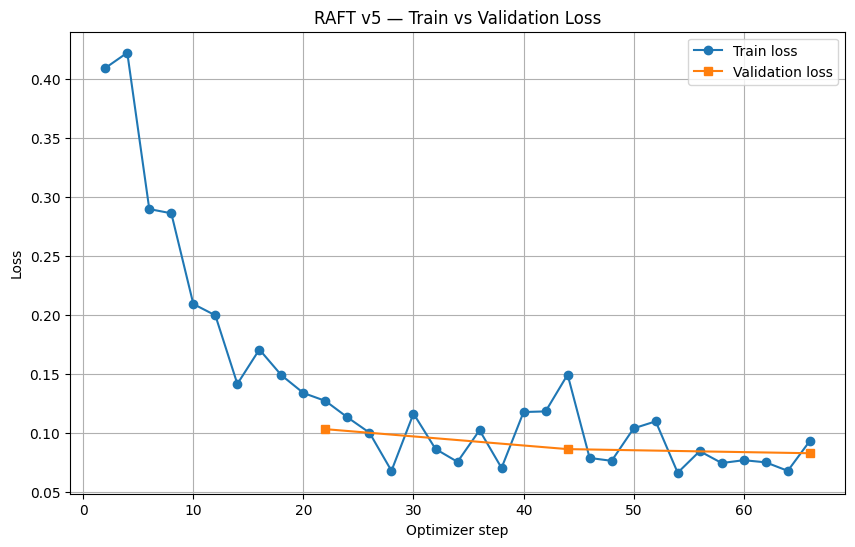

In [15]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_logs = [
    item for item in log_history
    if "loss" in item and "eval_loss" not in item
]
eval_logs = [
    item for item in log_history
    if "eval_loss" in item
]

plt.figure(figsize=(10, 6))

if train_logs:
    plt.plot(
        [item["step"] for item in train_logs],
        [item["loss"] for item in train_logs],
        marker="o",
        label="Train loss",
    )

if eval_logs:
    plt.plot(
        [item["step"] for item in eval_logs],
        [item["eval_loss"] for item in eval_logs],
        marker="s",
        label="Validation loss",
    )

plt.xlabel("Optimizer step")
plt.ylabel("Loss")
plt.title("RAFT v5 — Train vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

## 14. Ringkasan training

In [16]:
summary_rows = []

for item in trainer.state.log_history:
    summary_rows.append(
        {
            "step": item.get("step"),
            "epoch": item.get("epoch"),
            "loss": item.get("loss"),
            "eval_loss": item.get("eval_loss"),
            "learning_rate": item.get("learning_rate"),
        }
    )

metrics_dataframe = pd.DataFrame(summary_rows)
display(metrics_dataframe.tail(30))

print("=" * 72)
print("Best checkpoint :", trainer.state.best_model_checkpoint)
print("Best eval loss  :", trainer.state.best_metric)
print("Global step     :", trainer.state.global_step)
print("=" * 72)

,step,epoch,loss,eval_loss,learning_rate
0,2,0.117647,0.346148,NaN,0.000017
1,4,0.235294,0.351803,NaN,0.000050
2,6,0.352941,0.263647,NaN,0.000048
3,8,0.470588,0.216511,NaN,0.000046
4,10,0.588235,0.211011,NaN,0.000044
5,12,0.705882,0.192536,NaN,0.000042
6,14,0.823529,0.134472,NaN,0.000040
7,16,0.941176,0.151712,NaN,0.000038
8,17,1.000000,NaN,0.088729,NaN
9,18,1.058824,0.107375,NaN,0.000035


Best checkpoint : ../model/outputs_lora_V5/checkpoint-51
Best eval loss  : 0.07013505697250366
Global step     : 51


## 15. Inference dengan template yang sama

Evaluasi generation dilakukan terhadap model pada checkpoint terbaik yang otomatis dimuat kembali oleh Trainer.

In [16]:
FastLanguageModel.for_inference(model)


def generate_answer(
    instruction,
    documents,
    max_new_tokens=512,
):
    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": (
                f"Pertanyaan:\n{instruction.strip()}\n\n"
                f"Dokumen Referensi:\n"
                f"{format_documents(documents)}"
            ),
        },
    ]

    input_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to(model.device)

    attention_mask = torch.ones_like(input_ids)

    with torch.inference_mode():
        output_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    generated_ids = output_ids[0, input_ids.shape[1]:]

    return tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    ).strip()

## 16. Parser dan metrik generation

In [17]:
ID_LINE_PATTERNS = {
    "selected": re.compile(
        r"^KONTEKS_DIPILIH\s*:\s*(.*)$",
        re.IGNORECASE | re.MULTILINE,
    ),
    "rejected": re.compile(
        r"^KONTEKS_DITOLAK\s*:\s*(.*)$",
        re.IGNORECASE | re.MULTILINE,
    ),
}


def parse_document_id_line(text, field):
    match = ID_LINE_PATTERNS[field].search(text)
    if not match:
        return None

    value = match.group(1).strip()
    if value in {"", "-", "[]", "tidak ada"}:
        return []

    return sorted({
        int(number)
        for number in re.findall(r"\d+", value)
    })


def parse_final_answer(text):
    match = re.search(
        r"^JAWABAN\s*:\s*(.*)$",
        text,
        re.IGNORECASE | re.MULTILINE | re.DOTALL,
    )
    return match.group(1).strip() if match else ""


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def set_precision_recall_f1(predicted, expected):
    predicted = set(predicted)
    expected = set(expected)

    true_positive = len(predicted & expected)
    precision = safe_divide(true_positive, len(predicted))
    recall = safe_divide(true_positive, len(expected))
    f1 = safe_divide(
        2 * precision * recall,
        precision + recall,
    )
    return precision, recall, f1


def answer_token_f1(predicted, expected):
    predicted_tokens = re.findall(
        r"[a-z0-9]+",
        predicted.lower(),
    )
    expected_tokens = re.findall(
        r"[a-z0-9]+",
        expected.lower(),
    )

    if not predicted_tokens and not expected_tokens:
        return 1.0
    if not predicted_tokens or not expected_tokens:
        return 0.0

    predicted_counts = Counter(predicted_tokens)
    expected_counts = Counter(expected_tokens)

    overlap = sum(
        min(predicted_counts[token], expected_counts[token])
        for token in predicted_counts
    )

    precision = safe_divide(overlap, len(predicted_tokens))
    recall = safe_divide(overlap, len(expected_tokens))

    return safe_divide(
        2 * precision * recall,
        precision + recall,
    )

## 17. Evaluasi generation pada validation set

In [18]:
def evaluate_generation(
    dataset,
    split_name,
    max_examples=None,
):
    records = (
        list(dataset)
        if max_examples is None
        else list(dataset)[:max_examples]
    )

    rows = []

    for index, record in enumerate(records, start=1):
        raw_output = generate_answer(
            instruction=record["instruction"],
            documents=record["documents"],
        )

        predicted_selected = parse_document_id_line(
            raw_output,
            "selected",
        )
        predicted_rejected = parse_document_id_line(
            raw_output,
            "rejected",
        )
        predicted_answer = parse_final_answer(raw_output)

        expected_selected = sorted(
            record["selected_doc_ids"]
        )
        expected_rejected = sorted(
            record["rejected_doc_ids"]
        )

        document_count = len(record["documents"])
        valid_ids = set(range(1, document_count + 1))

        parsed = (
            predicted_selected is not None
            and predicted_rejected is not None
        )

        if parsed:
            predicted_partition = (
                set(predicted_selected)
                | set(predicted_rejected)
            )
            invalid_ids = predicted_partition - valid_ids
            overlap_ids = (
                set(predicted_selected)
                & set(predicted_rejected)
            )
            partition_complete = (
                predicted_partition == valid_ids
                and not overlap_ids
                and not invalid_ids
            )
        else:
            invalid_ids = set()
            partition_complete = False

        predicted_selected_for_metric = (
            predicted_selected
            if predicted_selected is not None
            else []
        )

        precision, recall, context_f1 = (
            set_precision_recall_f1(
                predicted_selected_for_metric,
                expected_selected,
            )
        )

        expected_answerable = bool(expected_selected)
        predicted_answerable = bool(
            predicted_selected_for_metric
        )

        rows.append(
            {
                "record_id": record["record_id"],
                "selected_exact": (
                    predicted_selected == expected_selected
                ),
                "rejected_exact": (
                    predicted_rejected == expected_rejected
                ),
                "partition_exact": (
                    predicted_selected == expected_selected
                    and predicted_rejected == expected_rejected
                ),
                "context_precision": precision,
                "context_recall": recall,
                "context_f1": context_f1,
                "answerability_correct": (
                    predicted_answerable
                    == expected_answerable
                ),
                "format_compliant": (
                    parsed and partition_complete
                ),
                "invalid_id_count": len(invalid_ids),
                "answer_token_f1": answer_token_f1(
                    predicted_answer,
                    record["completion"],
                ),
                "expected_selected": expected_selected,
                "predicted_selected": predicted_selected,
                "expected_rejected": expected_rejected,
                "predicted_rejected": predicted_rejected,
                "expected_answer": record["completion"],
                "predicted_answer": predicted_answer,
                "raw_output": raw_output,
            }
        )

        print(
            f"[{index:02d}/{len(records):02d}] "
            f"{record['record_id']} | "
            f"selected_exact={rows[-1]['selected_exact']} | "
            f"answer_f1={rows[-1]['answer_token_f1']:.3f}"
        )

    predictions = pd.DataFrame(rows)

    metric_columns = [
        "selected_exact",
        "rejected_exact",
        "partition_exact",
        "context_precision",
        "context_recall",
        "context_f1",
        "answerability_correct",
        "format_compliant",
        "answer_token_f1",
    ]

    metrics = {
        column: float(predictions[column].mean())
        for column in metric_columns
    }
    metrics["invalid_id_total"] = int(
        predictions["invalid_id_count"].sum()
    )
    metrics["num_examples"] = len(predictions)

    predictions_path = os.path.join(
        OUTPUT_DIR,
        f"{split_name}_generation_predictions.csv",
    )
    metrics_path = os.path.join(
        OUTPUT_DIR,
        f"{split_name}_generation_metrics.json",
    )

    predictions.to_csv(
        predictions_path,
        index=False,
        encoding="utf-8-sig",
    )
    with open(metrics_path, "w", encoding="utf-8") as file:
        json.dump(metrics, file, indent=2)

    return metrics, predictions


validation_metrics, validation_predictions = (
    evaluate_generation(
        validation_raw,
        split_name="validation",
    )
)

print("\nVALIDATION GENERATION METRICS")
print(
    json.dumps(
        validation_metrics,
        indent=2,
        ensure_ascii=False,
    )
)

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[01/43] raft-v5-0001 | selected_exact=True | answer_f1=0.959


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[02/43] raft-v5-0003 | selected_exact=False | answer_f1=1.000


...

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[09/43] raft-v5-0052 | selected_exact=False | answer_f1=0.611


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[10/43] raft-v5-0088 | selected_exact=False | answer_f1=0.524


KeyboardInterrupt: 

## 18. Evaluasi test set

Jalankan hanya setelah konfigurasi, hyperparameter, dan checkpoint sudah final. Jangan gunakan hasil test untuk mengubah training.

In [20]:
# Jalankan satu kali setelah eksperimen final:

test_metrics, test_predictions = evaluate_generation(
    test_raw,
    split_name="test",
)

print(
    json.dumps(
        test_metrics,
        indent=2,
        ensure_ascii=False,
    )
)

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[01/33] raft-v5-0086 | selected_exact=True | answer_f1=0.971


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[02/33] raft-v5-0098 | selected_exact=True | answer_f1=0.989


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[30/33] raft-v5-0355 | selected_exact=True | answer_f1=0.737


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[31/33] raft-v5-0361 | selected_exact=True | answer_f1=0.968


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[32/33] raft-v5-0371 | selected_exact=True | answer_f1=1.000
[33/33] raft-v5-0395 | selected_exact=True | answer_f1=0.716
{
  "selected_exact": 0.7575757575757576,
  "rejected_exact": 0.7575757575757576,
  "partition_exact": 0.7575757575757576,
  "context_precision": 0.798989898989899,
  "context_recall": 0.8181818181818182,
  "context_f1": 0.7919191919191919,
  "answerability_correct": 0.9090909090909091,
  "format_compliant": 1.0,
  "answer_token_f1": 0.7941947875477466,
  "invalid_id_total": 0,
  "num_examples": 33
}


## 19. Demo satu record

In [21]:
demo_record = validation_raw[0]

demo_output = generate_answer(
    instruction=demo_record["instruction"],
    documents=demo_record["documents"],
)

print("PERTANYAAN")
print(demo_record["instruction"])

print("\nEXPECTED SELECTED")
print(demo_record["selected_doc_ids"])

print("\nMODEL OUTPUT")
print(demo_output)

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PERTANYAAN
Apa yang dimaksud dengan "peraturan desa" menurut Peraturan Desa Biru No. 07 Tahun 2015, Pasal 1?

EXPECTED SELECTED
[4]

MODEL OUTPUT
KONTEKS_DIPILIH: 4
KONTEKS_DITOLAK: 1, 2, 3, 5

ALASAN_DOKUMEN:
- Dokumen 1: DITOLAK — tidak memuat fakta yang diminta
- Dokumen 2: DITOLAK — tidak memuat fakta yang diminta
- Dokumen 3: DITOLAK — tidak memuat fakta yang diminta
- Dokumen 4: DIPILIH — menjawab pertanyaan secara langsung
- Dokumen 5: DITOLAK — tidak memuat fakta yang diminta

JAWABAN:
Peraturan desa menurut Peraturan Desa Biru No. 07 Tahun 2015, Pasal 1, adalah kebijakan penyelenggaraan pemerintahan desa yang ditetapkan oleh kepala desa setelah mendapat persetujuan dari badan permusyawaratan desa.


## 20. Menyimpan adapter dan merged model

In [20]:
Path(ADAPTER_DIR).mkdir(parents=True, exist_ok=True)
Path(MERGED_DIR).mkdir(parents=True, exist_ok=True)

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print("LoRA adapter disimpan ke:", ADAPTER_DIR)

# model.save_pretrained_merged(
#     MERGED_DIR,
#     tokenizer,
#     save_method="merged_16bit",
# )

# print("Merged 16-bit model disimpan ke:", MERGED_DIR)

# run_config = {
#     "model_name": MODEL_NAME,
#     "max_seq_length": MAX_SEQ_LENGTH,
#     "load_in_4bit": LOAD_IN_4BIT,
#     "seed": SEED,
#     "train_dataset": TRAIN_DATASET_PATH,
#     "validation_dataset": VALIDATION_DATASET_PATH,
#     "test_dataset": TEST_DATASET_PATH,
#     "best_checkpoint": trainer.state.best_model_checkpoint,
#     "best_eval_loss": trainer.state.best_metric,
#     "sft_config": config_kwargs,
# }

# with open(
#     os.path.join(OUTPUT_DIR, "run_config.json"),
#     "w",
#     encoding="utf-8",
# ) as file:
#     json.dump(
#         run_config,
#         file,
#         ensure_ascii=False,
#         indent=2,
#         default=str,
#     )

print("Konfigurasi eksperimen disimpan.")

LoRA adapter disimpan ke: /workspace/model/lora_adapter_raft_v5
Konfigurasi eksperimen disimpan.


## 21. Membersihkan VRAM (opsional)

In [ ]:
# Jalankan hanya setelah training, evaluasi, dan penyimpanan selesai.

del trainer
del model
gc.collect()
torch.cuda.empty_cache()
print("VRAM dibersihkan.")